## Kaggle BT4012
Student ID: E0957731

## Load Dataset for visualisation


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, accuracy_score, f1_score, roc_auc_score

# Load the datasets
train_df = pd.read_csv('bt-4012-in-class-kaggle-competition-2024-nov/train.csv')
test_df = pd.read_csv('bt-4012-in-class-kaggle-competition-2024-nov/test.csv')
sample_submission_df = pd.read_csv('bt-4012-in-class-kaggle-competition-2024-nov/sample_submission.csv')

train_df = train_df.copy()
test_df = test_df.copy()
sample_submission_df = sample_submission_df.copy()

# Display the first few rows of the training dataset to understand its structure
train_df.head()

,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,lang,location,profile_background_image_url,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,target
0,2012-01-15 23:40:09,True,False,Cosplayer/Fitness lover. Come to me https://t....,74,7,0,False,465096524,en,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/9666745212...,reml5477,20,False,0.006,3138,1
1,2016-10-04 00:44:39,False,False,pobody’s nerfect,50443,164,590,True,783105517673648132,cy,she/her,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1281752126...,kinlibra,6469,False,4.572,1415,0
2,2009-05-23 04:04:13,False,False,gracias por participar 🏅,9394,208,189,False,41970759,es,La diaspora,http://abs.twimg.com/images/themes/theme17/bg.gif,http://pbs.twimg.com/profile_images/1233811596...,_delaualau,30296,False,7.378,4106,0
3,2009-05-17 04:31:31,False,False,Stand Up Comedian/Actor from North Philadelphi...,46,66180,1090,True,40607946,en,"Calabasas, CA",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1184851104...,SpankHorton,164957,False,40.116,4112,0
4,2009-02-16 13:11:21,True,False,Assignment Editor at NBC10 and President of Ja...,1223,487,867,True,20983433,en,"Jenkintown, PA",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/5234863934...,javelinjt,1752,False,0.417,4201,0


## Check for duplicated rows
- no duplicated rows were found

In [2]:
duplicates = train_df.duplicated()
num_duplicates = duplicates.sum()

print(f"Number of duplicated rows: {num_duplicates}")

Number of duplicated rows: 0


## Check for imbalanced dataset
- data is slightly imbalanced but can be dealt with through k-folds cross validation

Target Distribution:
 target
0    0.664848
1    0.335152
Name: proportion, dtype: float64


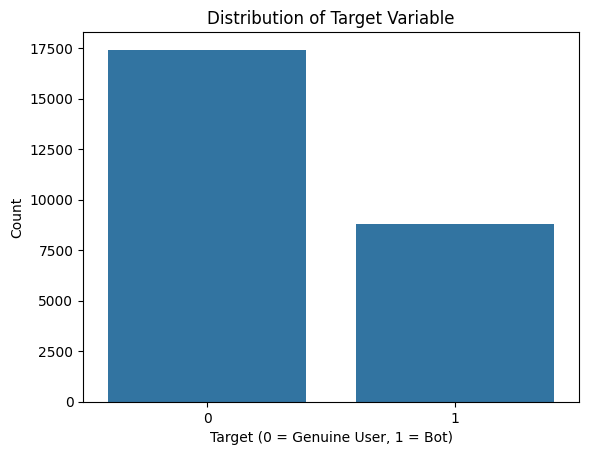

In [3]:
# Check the distribution of the target variable
target_counts = train_df['target'].value_counts(normalize=True)
print("Target Distribution:\n", target_counts)

# Visualize the distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=train_df, x='target')
plt.title("Distribution of Target Variable")
plt.xlabel("Target (0 = Genuine User, 1 = Bot)")
plt.ylabel("Count")
plt.show()


## Handle missing data

Upon inspecting the dataset, there are several fields with null values. Since these fields are all categorical, I decided to fill the missing values with the appropriate categorical values:

- Missing values filled with **"Unknown"**: Used for columns like `description`,`lang`,`location` where missing data likely means the information is unavailable or not applicable. This preserves the understanding that the data may exist but is not provided.

In [4]:
# Check for missing values in the training dataset
missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Missing values summary:", missing_values)

# Impute missing values
train_df['description'] = train_df['description'].fillna('unknown')
train_df['lang'] = train_df['lang'].fillna('unknown')
train_df['location'] = train_df['location'].fillna('unknown')

test_df['description'] = test_df['description'].fillna('unknown')
test_df['lang'] = test_df['lang'].fillna('unknown')
test_df['location'] = test_df['location'].fillna('unknown')


Missing values summary: description                     5091
lang                            5588
location                           2
profile_background_image_url    3235
profile_image_url                  1
dtype: int64


## Drop url columns and check for any missing data
- the url columns 

In [5]:
# Drop 'profile_background_image_url' and 'profile_image_url' as they are less informative
train_df.drop(columns=['profile_background_image_url', 'profile_image_url'], inplace=True)
test_df.drop(columns=['profile_background_image_url', 'profile_image_url'], inplace=True)

# Verify there are no missing values left
assert train_df.isnull().sum().sum() == 0, "There are still missing values"

## Feature Engineering

### Consider
    - followers_count to friends_count ratio
    - followers_count to account_age_days ratio
    - statuses_count to followers_count ratio
    - favourites_count to account_age_days ratio 
    - verified to target to check if being verified has any correlation to being a bot account
    - account_age_days to target to check if age of account has any correlation to being a bot account
    - geo_enabled to target to check if there is a correlation between enabling location services and bot accounts

            created_at  default_profile  default_profile_image  \
0  2012-01-15 23:40:09             True                  False   
1  2016-10-04 00:44:39            False                  False   
2  2009-05-23 04:04:13            False                  False   
3  2009-05-17 04:31:31            False                  False   
4  2009-02-16 13:11:21             True                  False   

                                         description  favourites_count  \
0  Cosplayer/Fitness lover. Come to me https://t....                74   
1                                   pobody’s nerfect             50443   
2                           gracias por participar 🏅              9394   
3  Stand Up Comedian/Actor from North Philadelphi...                46   
4  Assignment Editor at NBC10 and President of Ja...              1223   

   followers_count  friends_count  geo_enabled                  id lang  ...  \
0                7              0        False           465096524   en  ...  

<Figure size 800x500 with 0 Axes>

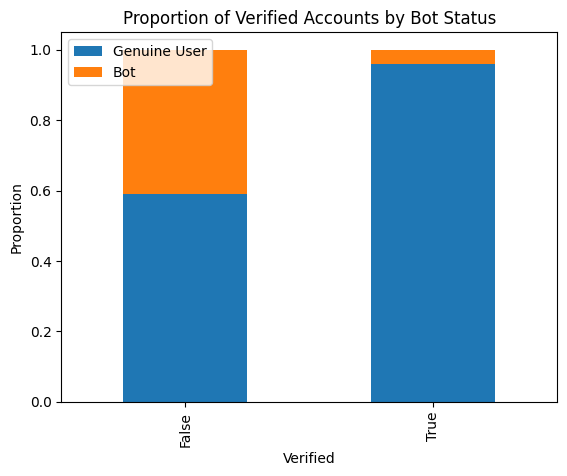

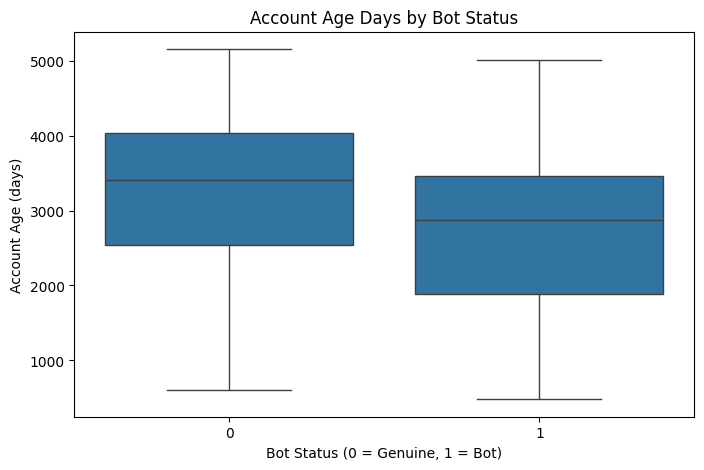

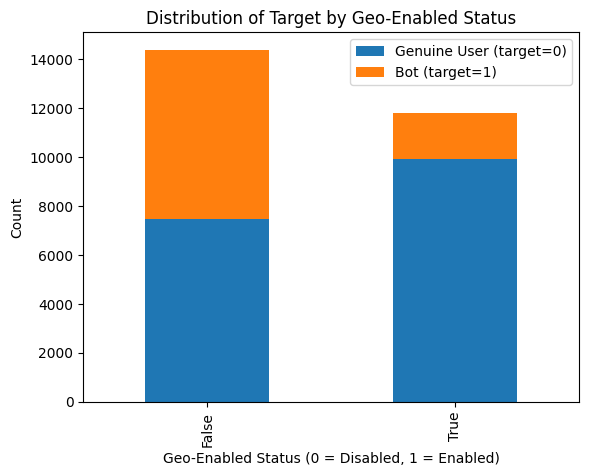

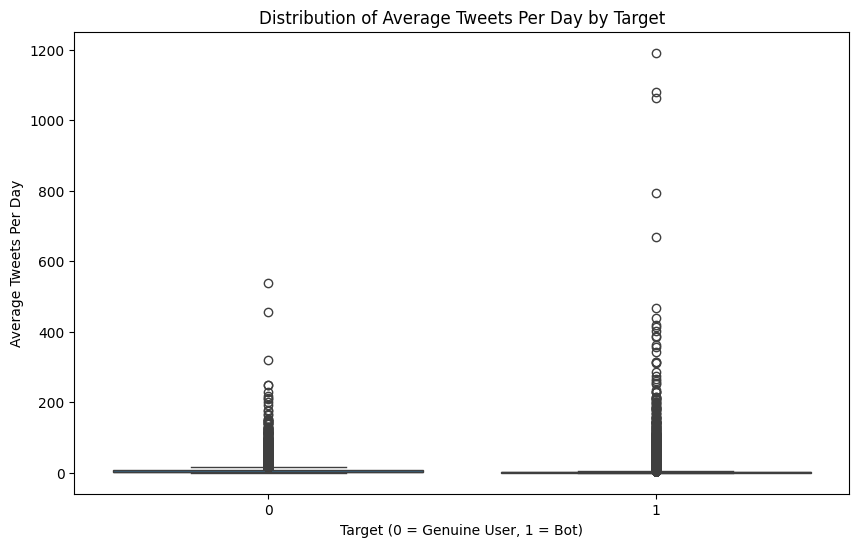

In [6]:
train_df['followers_friends_ratio'] = train_df['followers_count'] / (train_df['friends_count'] + 1e-5)
train_df['followers_per_day'] = train_df['followers_count'] / (train_df['account_age_days'] + 1e-5)
train_df['statuses_per_follower'] = train_df['statuses_count'] / (train_df['followers_count'] + 1e-5)
train_df['favourites_per_day'] = train_df['favourites_count'] / (train_df['account_age_days'] + 1e-5)


#Repeat for test_df

test_df['followers_friends_ratio'] = test_df['followers_count'] / (test_df['friends_count'] + 1e-5)
test_df['followers_per_day'] = test_df['followers_count'] / (test_df['account_age_days'] + 1e-5)
test_df['statuses_per_follower'] = test_df['statuses_count'] / (test_df['followers_count'] + 1e-5)
test_df['favourites_per_day'] = test_df['favourites_count'] / (test_df['account_age_days'] + 1e-5)


print(train_df.head())

import matplotlib.pyplot as plt
import seaborn as sns

# Verified vs. Target
verified_counts = train_df.groupby(['verified', 'target']).size().unstack()
verified_proportions = verified_counts.div(verified_counts.sum(axis=1), axis=0)

# Plot verified to target comparison
plt.figure(figsize=(8, 5))
verified_proportions.plot(kind='bar', stacked=True)
plt.title("Proportion of Verified Accounts by Bot Status")
plt.xlabel("Verified")
plt.ylabel("Proportion")
plt.legend(["Genuine User", "Bot"])
plt.show()

# Account Age vs. Target
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='account_age_days', data=train_df)
plt.title("Account Age Days by Bot Status")
plt.xlabel("Bot Status (0 = Genuine, 1 = Bot)")
plt.ylabel("Account Age (days)")
plt.show()

# Group by 'geo_enabled' and 'target' and count occurrences
geo_enabled_counts = train_df.groupby(['geo_enabled', 'target']).size().unstack()

# Plot the distribution of target based on geo_enabled
geo_enabled_counts.plot(kind='bar', stacked=True)
plt.title("Distribution of Target by Geo-Enabled Status")
plt.xlabel("Geo-Enabled Status (0 = Disabled, 1 = Enabled)")
plt.ylabel("Count")
plt.legend(["Genuine User (target=0)", "Bot (target=1)"])
plt.show()

# Set the plot size
plt.figure(figsize=(10, 6))

# Create a boxplot for average_tweets_per_day vs target
sns.boxplot(data=train_df, x='target', y='average_tweets_per_day')
plt.title("Distribution of Average Tweets Per Day by Target")
plt.xlabel("Target (0 = Genuine User, 1 = Bot)")
plt.ylabel("Average Tweets Per Day")
plt.show()



## Create new columns based on insights
- we can separate the account ages into bins for better recognition by the model later on
- geo_enabled and verified are already binary columns so we do not have to do further editing to utilise them
- we can create a composite feature that flags low age, high average tweets per day accounts as bots 

In [7]:
# Binning account_age_days into categories
# Define the bins based on quartiles or specific cutoffs
train_df['account_age_category'] = pd.cut(
    train_df['account_age_days'],
    bins=[0, 365, 730, 1825, train_df['account_age_days'].max()],
    labels=["Very New", "New", "Established", "Old"]
)

# Encode the new 'account_age_category' feature as numerical categories
train_df['account_age_category'] = train_df['account_age_category'].cat.codes


# Define thresholds based on quantiles
tweet_frequency_threshold = train_df['average_tweets_per_day'].quantile(0.90)  # 90th percentile for high tweets
account_age_threshold = 365  # 1 year (365 days) as the threshold for low account age

# Create a composite feature that flags accounts with high tweet frequency and low account age
train_df['high_tweet_low_age'] = ((train_df['average_tweets_per_day'] > tweet_frequency_threshold) & 
                                  (train_df['account_age_days'] < account_age_threshold)).astype(int)




# Evaluate how well this new feature aligns with the target
from sklearn.metrics import accuracy_score, confusion_matrix

# Calculate accuracy of high_tweet_low_age in identifying bots
accuracy_composite = accuracy_score(train_df['target'], train_df['high_tweet_low_age'])
print("Accuracy of High Tweet Frequency & Low Account Age Flag in Identifying Bots:", accuracy_composite)


##Repeat for test

# Define the bins based on quartiles or specific cutoffs
test_df['account_age_category'] = pd.cut(
    test_df['account_age_days'],
    bins=[0, 365, 730, 1825, test_df['account_age_days'].max()],
    labels=["Very New", "New", "Established", "Old"]
)

# Encode the new 'account_age_category' feature as numerical categories
test_df['account_age_category'] = test_df['account_age_category'].cat.codes


# Define thresholds based on quantiles
tweet_frequency_threshold = test_df['average_tweets_per_day'].quantile(0.90)  # 90th percentile for high tweets
account_age_threshold = 365  # 1 year (365 days) as the threshold for low account age

# Create a composite feature that flags accounts with high tweet frequency and low account age
test_df['high_tweet_low_age'] = ((test_df['average_tweets_per_day'] > tweet_frequency_threshold) & 
                                  (test_df['account_age_days'] < account_age_threshold)).astype(int)



Accuracy of High Tweet Frequency & Low Account Age Flag in Identifying Bots: 0.6648477447912692


## Label encode relevant columns

In [8]:
# Encode categorical features
label_encoder = LabelEncoder()
train_df['default_profile'] = label_encoder.fit_transform(train_df['default_profile'])
train_df['default_profile_image'] = label_encoder.fit_transform(train_df['default_profile_image'])
train_df['geo_enabled'] = label_encoder.fit_transform(train_df['geo_enabled'])
train_df['verified'] = label_encoder.fit_transform(train_df['verified'])

test_df['default_profile'] = label_encoder.transform(test_df['default_profile'])
test_df['default_profile_image'] = label_encoder.transform(test_df['default_profile_image'])
test_df['geo_enabled'] = label_encoder.transform(test_df['geo_enabled'])
test_df['verified'] = label_encoder.transform(test_df['verified'])

# In training data, define the categories and store them
train_df['lang'] = pd.Categorical(train_df['lang'])
lang_categories = train_df['lang'].cat.categories

# Convert to numeric codes based on categories in training data
train_df['lang'] = train_df['lang'].cat.codes

# In test data, set categories to match those from training
test_df['lang'] = pd.Categorical(test_df['lang'], categories=lang_categories)

# Convert to numeric codes, using -1 for any unseen categories
test_df['lang'] = test_df['lang'].cat.codes.fillna(-1).astype(int)


## Textual Preprocessing
Clean textual columns by
- removing special characters
- removing stopwords
- performing tokenization
- performing lemmatization

In [9]:
abbreviation_mapping = {
    "Avi": "avatar or profile picture",
    "B/C": "because",
    "B4": "before",
    "BB": "blackberry",
    "BFN": "bye for now",
    "Bgd": "background",
    "BR": "best regards",
    "BTW": "by the way",
    "Chk": "check",
    "Cld": "could",
    "Clk": "click",
    "Cre8": "create",
    "CUL8R": "see you later",
    "CT": "'cutweet' a retweet that’s been shortened",
    "Cya": "see you",
    "Deets": "details",
    "DAM": "don’t annoy me",
    "DM": "direct message",
    "DP": "profile picture",
    "Dweet": "tweet sent while drunk",
    "DYK": "did you know?",
    "EM": "email",
    "Eml": "email",
    "EMA": "email address",
    "F2F": "face to face",
    "FF": "Follow Friday",
    "FML": "f**k my life",
    "FOTD": "find of the day",
    "FTL": "for the loss",
    "FTW": "for the win or f**k the world",
    "Fwd": "forward",
    "FYI": "for your information",
    "GLHF": "good luck have fun",
    "GM": "good morning",
    "Gr8": "great",
    "GTFOH": "get the f**k outta here!",
    "GTS": "guess the song",
    "HAND": "have a nice day",
    "HO": "hangover",
    "HT": "hat tip or heard through",
    "IC": "I see",
    "ICNBI": "I cannot believe it",
    "ICYMI": "in case you missed it",
    "IDK": "I don’t know",
    "IM": "instant message",
    "IMO": "in my opinion",
    "IMHO": "in my humble opinion",
    "IYKWIM": "if you know what I mean",
    "IRL": "in real life",
    "Itz": "it is",
    "JK": "just kidding",
    "JSYK": "just so you know",
    "JW": "just wondering",
    "K": "okay",
    "KK": "cool, cool",
    "KYSO": "knock your socks off",
    "L2S": "life’s too short",
    "L8": "late",
    "L8r": "later",
    "LHH": "laugh hella hard",
    "LOL": "laughing out loud or lots of love",
    "LMAO": "laughing my a** off",
    "LMFAO": "laughing my f***ing a** off",
    "LMK": "let me know",
    "Mil": "million or mother-in-law",
    "MILT": "mum I’d like to tweet!",
    "MT": "modified tweet",
    "Njoy": "enjoy",
    "NSFW": "not safe for work",
    "NW": "now watching",
    "OCT": "obsessive compulsive tweeter",
    "OH": "overheard or other half",
    "OMB": "oh my god (Bieber)",
    "OMG": "oh my god",
    "OOMF": "one of my followers",
    "Peeps": "people",
    "Plz": "please",
    "Ppl": "people",
    "Props": "proper respect",
    "R": "are",
    "Rec": "recommendation",
    "RT": "retweet",
    "RTHX": "thanks for the retweet",
    "RU": "are you?",
    "SEO": "search engine optimization",
    "Shld": "should",
    "SMH": "shake my head",
    "STFU": "shut the f**k up",
    "Speets": "spam tweets",
    "Sweeple": "sweet twitter people",
    "Swhit": "tweeting while on the toilet",
    "TA": "thanks a lot",
    "TBH": "to be honest",
    "TJ": "joining into someone else’s conversation",
    "TFF": "twitter friend forever",
    "TFTT": "thanks for this tweet",
    "TTFN": "ta ta for now",
    "TGIF": "thank God it’s Friday!",
    "Thx": "thanks",
    "TY": "thank you",
    "TIA": "thanks in advance",
    "TL": "timeline",
    "TOYBT": "tired of your bulls**t",
    "TT": "trending topic",
    "TTYL": "talk to you later",
    "TTYS": "talk to you soon",
    "TYL": "tweet y’all later",
    "U": "you",
    "Vols": "volunteers",
    "W": "with",
    "W/E": "weekend",
    "Wld": "would",
    "WTF": "what the f**k?",
    "WTH": "what the hell?",
    "Wtv": "whatever",
    "WLTM": "would like to meet",
    "Wzup": "what’s up?",
    "xoxo": "hugs and kisses",
    "YKIM": "you know what I mean",
    "Ykyat": "you know you’re addicted to",
    "YOLO": "you only live once",
    "YOYO": "you’re on your own",
    "YW": "you’re welcome"
}


In [10]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from textblob import TextBlob
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
from tqdm import tqdm
import string 

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')

def handle_repeated_chars(text):
    # Reduce repeated characters to just two (e.g., cooool -> cool)
    return re.sub(r'(.)\1+', r'\1\1', text)

def expand_abbreviations(text):
    words = text.split()
    return ' '.join([abbreviation_mapping.get(word, word) for word in words])

# Entity Recognition (NER) using NLTK POS tagging
def named_entity_recognition(text):
    words = word_tokenize(text)
    pos_tagged = nltk.pos_tag(words)
    entities = [word for word, pos in pos_tagged if pos in ['NNP', 'NNPS']]  # Extract proper nouns as entities
    return ' '.join(entities)

def preprocess_text(text):
    text = text.lower()
    text = handle_repeated_chars(text)
    text = expand_abbreviations(text)

    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)

    tokens = word_tokenize(text)

    return tokens

def remove_stopwords(tokens):
    stop_words = set(stopwords.words('english'))
    negations = {"no", "nor", "not"}
    stop_words = stop_words - negations
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return filtered_tokens

def perform_lemmatization(tokens):
    lemmer = nltk.WordNetLemmatizer()
    lem_tokens = [lemmer.lemmatize(token) for token in tokens]
    return lem_tokens

def clean_text(text):
    tokens = preprocess_text(text)
    tokens = remove_stopwords(tokens)
    tokens = perform_lemmatization(tokens)
    clean_text = ' '.join(tokens)
    return clean_text

def extract_entities(text):
    return named_entity_recognition(text)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Aftershock\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Aftershock\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Aftershock\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [19]:
columns = ['description','screen_name']

for col in columns:
    train_df[f'{col}_cleaned'] = train_df[col].apply(clean_text)
    test_df[f'{col}_cleaned'] = test_df[col].apply(clean_text)

#TF-IDF these columns

# Initialize TF-IDF Vectorizer for the textual columns
tfidf_description = TfidfVectorizer(max_features=100)
tfidf_screen_name = TfidfVectorizer(max_features=50)

# Fit and transform the cleaned description and screen name for training and test data
tfidf_description_train = tfidf_description.fit_transform(train_df['description_cleaned'].fillna(''))
tfidf_screen_name_train = tfidf_screen_name.fit_transform(train_df['screen_name_cleaned'].fillna(''))

tfidf_description_test = tfidf_description.fit_transform(test_df['description_cleaned'].fillna(''))
tfidf_screen_name_test = tfidf_screen_name.fit_transform(test_df['screen_name_cleaned'].fillna(''))


## Model predictions on test data

In [ ]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.sparse import hstack

# Prepare the features (X) and target (y)
X_train = train_df.drop(columns=['target', 'created_at', 'description', 'screen_name', 'id', 'location'])
y_train = train_df['target']

X_train = pd.get_dummies(X_train, drop_first=True)

# Initialize the XGBoost model
xgb_model = XGBClassifier(random_state=42,enable_categorical = True)

# Set up hyperparameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'colsample_bytree': [0.5, 0.7, 1],
    'subsample': [0.6, 0.8, 1]
}

# Set up RandomizedSearchCV with cross-validation
random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# Run RandomizedSearchCV to find the best hyperparameters
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

# Print the best parameters
print("Best Parameters:", random_search.best_params_)

# Train the best model on the entire training set
best_model.fit(X_train, y_train)

# Prepare the test features
X_test = test_df.drop(columns=['created_at', 'description', 'screen_name', 'id', 'location','index'])

X_test = pd.get_dummies(X_test, drop_first=True)

# Predict the probabilities on the test data with the best model
test_probabilities = best_model.predict_proba(X_test)[:, 1]

# Load the sample submission file
sample_submission_df = pd.read_csv('bt-4012-in-class-kaggle-competition-2024-nov/sample_submission.csv')

# Add the predicted probabilities to the 'target' column in the submission file
sample_submission_df['target'] = test_probabilities

# Save the submission file with predicted probabilities
sample_submission_df.to_csv('submission.csv', index=False)

print("Probability predictions saved to submission.csv for submission.")
